#data context and data sampling

This data is pulled from the Public Welltory `hrv-covid19` GitHub repository. The repository contains separate CSV files for participant information, heart rate, heart-rate variability, sleep, blood pressure, surveys, wearable devices, weather, and measurement-scale descriptions.

The repository does not specifcy exactly how participants were chosen, what the purpose of the survey was, or the sampling frequency. For this analysis, the data is treated as an observational sample. Conclusions will be limited to patterns found within the available records rather than claims about the broader population. 

Within the participants.csv dataset, the identified variables were user code, gender, age range, city, country, height, weight, and symptoms onset. The city, height, and sympots onset columns have missing inputs.

I chose to look at the participants dataset because I am interested in demographic information and wanted to analyze demographic insights.



In [12]:
#Explore and interpret data structure, descriptive statistics, data quality, and variable relationships

import pandas as pd
df = pd.read_csv('participants.csv')

# Explore the data structure
print("Below is the data structure of the dataset:")
print("")
print("Below are the first 5 rows of the dataset:")
print("")
print(df.head())
print("Below is the information about the dataset:")
print("")
print(df.info())
print("")

# Descriptive statistics
print("Below are the descriptive statistics for the dataset:")
print("")
print("Descriptive statistics for all variables:")
print("")
print(df.describe(include="all"))
print("")
print("Number of unique user codes:")
print("")
print(df["user_code"].nunique())
print("")
print("Number of unique age ranges:")
print("")
print(df["age_range"].value_counts())
print("")
print("Number of unique genders:")
print("")
print(df["gender"].value_counts())
print("")
print("Number of unique countries:")
print("")
print(df["country"].value_counts())
print("")


# Data quality
print("Below is the data quality assessment for the dataset:")
print("")
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())


Below is the data structure of the dataset:

Below are the first 5 rows of the dataset:

    user_code gender age_range           city  country  height  weight  \
0  007b8190cf      m     25-34       Mandalay  Myanmar  170.18  96.162   
1  013f6d3e5b      f     18-24      São Paulo   Brazil  174.00  77.300   
2  01bad5a519      m     45-54  St Petersburg   Russia  178.00  92.000   
3  0210b20eea      f     25-34          Sochi   Russia  169.00  60.000   
4  024719e7da      f     45-54  St Petersburg   Russia  158.00  68.500   

  symptoms_onset  
0            NaN  
1      5/15/2020  
2       4/5/2020  
3       5/6/2020  
4      5/27/2020  
Below is the information about the dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_code       185 non-null    object 
 1   gender          185 non-null    object 
 2   age_range       18

Interpretation of data frame

The dataframe has 185 rows and 8 columns. Height, city, and country have some missing valies. The average height was 169.98 and average weight was 77.93. Though metrics were not explicitly conveyed, we can reasonably interpret that height is in centimeters and weight is in KGs. 

There were no duplicated rows, the most repeated age range was 35-44 followed by 45-54, and female was tested 51 more times than male. Russia was the country with the largest sample size, followed by the US. 

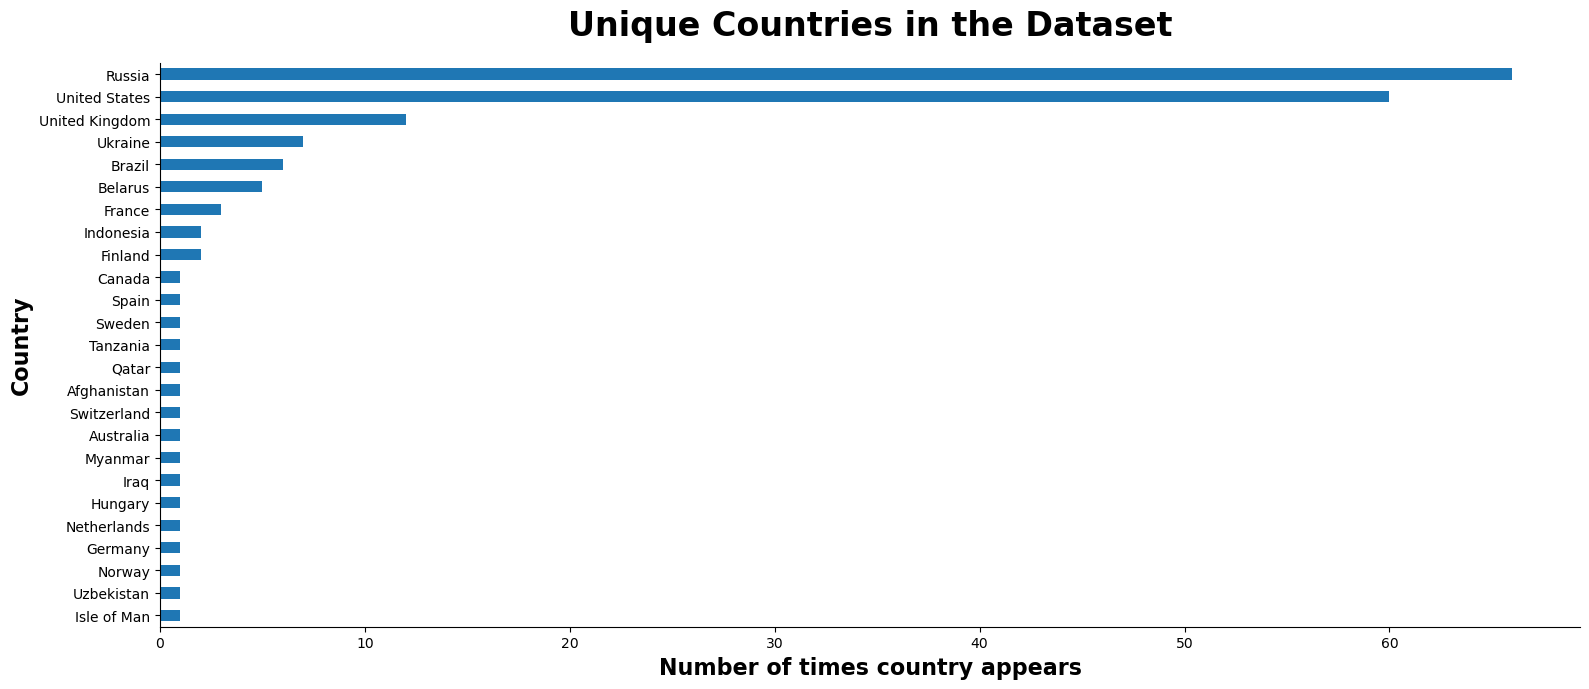

In [13]:
#Data Visualizations for Countries

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('participants.csv')

# Create Figure and Axes
fig, ax = plt.subplots(figsize = (16, 7))     

# Create variable
unique_countries = df["country"].value_counts().sort_values(ascending=True)

# Plot the data
unique_countries.plot.barh(
    x='country', 
    y='count', 
    ax=ax, 
    legend=False
)

# Set labels and title
ax.set_xlabel('Number of times country appears', size=16, weight='bold')
ax.set_ylabel('Country', size=16, weight='bold')
ax.set_title('Unique Countries in the Dataset', size=24, weight='bold', pad = 20)

# Remove borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Show the plot
plt.tight_layout()
plt.show()


# identify country after eliminating duplicating user codes


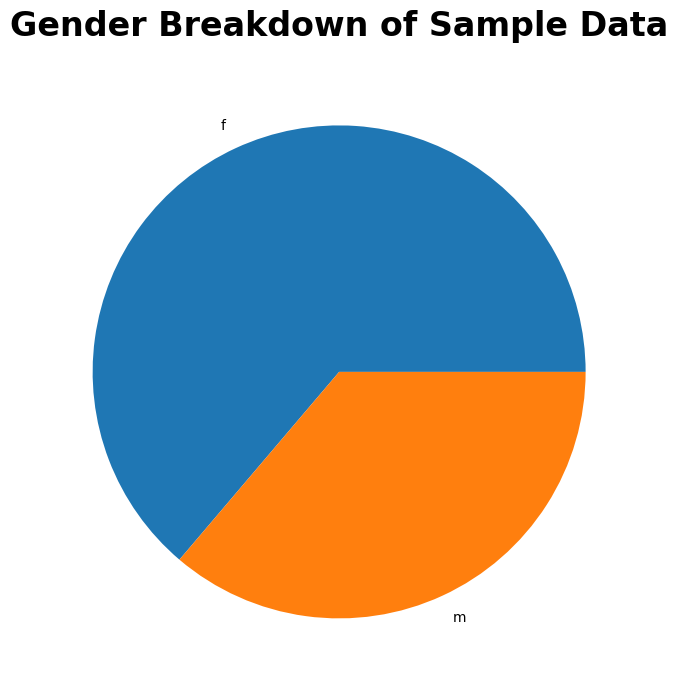

In [14]:
#Data visualizations for gender breakdown of sample size

import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('participants.csv')

# Create Figure and Axes
fig, ax = plt.subplots(figsize = (16, 7))     

# Create variable
gender_counts = df['gender'].value_counts()

# Plot the data
plt.pie(gender_counts, labels=gender_counts.index)

# Set labels and title
ax.set_title('Gender Breakdown of Sample Data', size=24, weight='bold', pad = 20)

# Remove borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Show the plot
plt.tight_layout()
plt.show()

The data visualizations show the proportion of countries represented in dataset. Russia and US are the top countries. The second visualization shows the distribution of female vs male particpants surveyed. There was a higher percentage of female participants surveyed versus male.  

In [15]:
import pandas as pd

df = pd.read_csv('participants.csv')


# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['height'].quantile(0.25)
Q3 = df['height'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter the DataFrame to find outliers
lower_outliers = df[(df['height'] < lower_bound)]
upper_outliers = df[(df['height'] > upper_bound)]
print("Lower outliers:")
print(lower_outliers[['height']])
print("Upper outliers:")
print(upper_outliers[['height']])
print("")
print("Mean:")
print(df['height'].mean())
print("Standard Deviation:")
print(df['height'].std())


Lower outliers:
    height
65  132.08
Upper outliers:
     height
49   248.92
83   203.00
102  250.00
136  193.00
175  193.00

Mean:
169.97639344262296
Standard Deviation:
12.400103070218595


In [ ]:
# Populating height with mean value for missing values

import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np

df = pd.read_csv('participants.csv')

#creating a new df that populates missing values in height with the mean of the column as well as the extreme outliers with mean height value
df_mean = df.copy()

#mark the extreme height values as missing
df_mean.loc[[49, 102], "height"] = np.nan

#use mean imputer to fill in missing values
mean_imputer = SimpleImputer(strategy="mean")
df_mean[['height']] = mean_imputer.fit_transform(df_mean[['height']])
print(df_mean)



      user_code gender age_range           city        country  height  \
0    007b8190cf      m     25-34       Mandalay        Myanmar  170.18   
1    013f6d3e5b      f     18-24      São Paulo         Brazil  174.00   
2    01bad5a519      m     45-54  St Petersburg         Russia  178.00   
3    0210b20eea      f     25-34          Sochi         Russia  169.00   
4    024719e7da      f     45-54  St Petersburg         Russia  158.00   
..          ...    ...       ...            ...            ...     ...   
180  fd387f6269      f     35-44      Attleboro  United States  165.00   
181  fdc881a0a8      f     55-64         Moscow         Russia  160.00   
182  fde84801d8      f     45-54         Tambov         Russia  168.00   
183  fe5ca7e4ea      m     35-44  Dar es Salaam       Tanzania  168.00   
184  fe6c1b1349      f     25-34         Moscow         Russia  173.00   

      weight symptoms_onset  
0     96.162            NaN  
1     77.300      5/15/2020  
2     92.000       4/

From my last two code cells, I identified that there were 6 outliers for height (the onlu numerical column with missing values), two of which were extreme. ~248 and ~250cm are both above 8 feet. This indicates that it was likely human error. Therefore, I calculated the mean after replacing those values with NA so as to not skew the true mean, and populated all missing values with the mean. I did not populate the other columns since they were not numerical. 

In [17]:
#Creating a new variable of BMI to continue to help with the analysis of the dataset and potentially remove the need for both height and weight variables in the future.

import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np

df = pd.read_csv('participants.csv')

#creating a new df to hold BMI values calculated from height and weight
df_BMI = df.copy()

#creatigng new BMI variable by dividing weight by height in meters squared (height is in cm so we divide by 100 to convert to meters)
df_BMI['BMI'] = df_BMI['weight'] / ((df_BMI['height']//100) ** 2)

print(df_BMI[['height', 'weight', 'BMI']])

     height   weight      BMI
0    170.18   96.162   96.162
1    174.00   77.300   77.300
2    178.00   92.000   92.000
3    169.00   60.000   60.000
4    158.00   68.500   68.500
..      ...      ...      ...
180  165.00  115.439  115.439
181  160.00   53.000   53.000
182  168.00   79.500   79.500
183  168.00   87.500   87.500
184  173.00   53.000   53.000

[185 rows x 3 columns]


General data quality assessment is that though there were fewer missing data fields than other datasets, there was no context in how data was collected, which caused issues during review to be able to identify true outliers, any sort of potential human error, or generally gain more context on the quality of data collected. 

Particpants are shown to be collected from across the world - the minimum context given in how this data was collected also limits our understanding of data consistency and integrity. If individuals were independtly submitting responses, how can we be sure metrics were consistent across the board? For example, one entry was 115 for weight, what I have assumed is KG due to the other entries. However, what if that particpant meant to record pounds?

Lastly, there is no detail on data ownership or provenance. I do not know if or how many times this dataset has been touched or how it has been moved. This all impacts data integrity. 